# `fit_sinewave`: Fitting a sine wave with an artificial neural network (ANN)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/dmhuehol/ml-workshop-cuni/blob/main/fit_sinewave.ipynb)

Lightly updated by [Daniel Hueholt](https://hueholt.earth) from original version used in Arcodia et al. 2022 "Applied Machine Learning Tutorial for Earth Scientists": [Zenodo link to original](https://doi.org/10.5281/zenodo.6686878).  

*Code originally by [Emily Gordon](https://emilymgordon.com) and [Frances Davenport](https://fdavenport.github.io).*

In [2]:
# import packages, set random seed

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# set random seed
random_seed = 36
tf.random.set_seed(int(random_seed))
np.random.seed(int(random_seed))

# nice figures
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['figure.dpi']= 150
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.size'] = 12

## Make data
First we make the data that we will attempt to fit. This consists of Nsamples that range between -1 and 1 for our input `xdata`, and the sine of this input as output

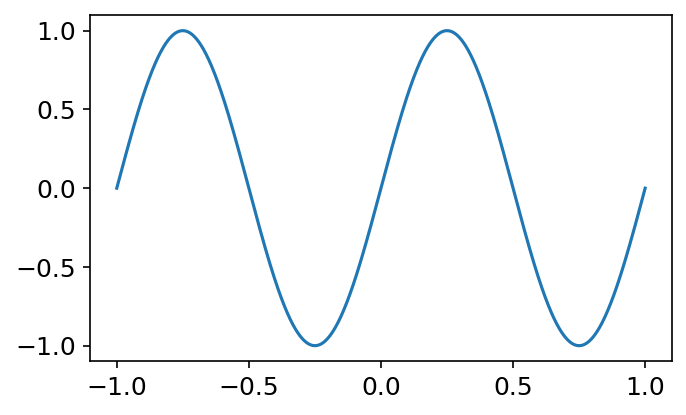

In [3]:
Nsamples = 1000

xdata = np.linspace(-1, 1, Nsamples)
ydata = np.sin(2 * np.pi * xdata)

plt.figure(figsize=(5,3))
plt.plot(xdata, ydata)
plt.show()

## Now make some training and validation pairs
One way we can split into training, validation and testing is we grab a random 50% of data from the above sine wave for our training data. Then we further grab 25% from the remaining chunk for the validation data. This way, validation data is representative of the function, but does not repeat the training data. The last chunk of the data is used for testing. For this method set `randomselect=1`.

Another way to do this is by dividing the data into evenly spaced chunks. This way, there is less auto-correlation between the samples in the training, validation and testing. For this method, set `randomselect=0`.

In [4]:
randomselect = 1

# Determine shapes: grab 50% of data for training, then 25% of remaining data for validation, and last chunk for testing
Nfull = xdata.shape[0]
Ntrain = int(Nfull * 0.5)
Nval = int(Nfull * 0.25)
Ntest = int(Nfull * 0.25)


if randomselect == 1:
    allind = np.random.choice(np.arange(Nfull),size=Nfull,replace=False) 
    trainind = allind[:Ntrain]
    valind = allind[Ntrain:Ntrain+Nval]
    testind = allind[Ntrain+Nval:]

else:
    division = 200
    trainind = []
    valind = []
    testind = []
    for i in range(int(Nsamples/division)):
        # print(i)
        trainind = trainind + list(range(division*i, int(division*i+division/4))) + list(range(int(division*i+division*3/4), division*(i+1)))
        valind = valind + list(range(int(division*i+division/4), int(division*i+division/2)))
        testind = testind + list(range(int(division*i+division/2), int(division*i+division*3/4)))

We then make figures to explore the data to get a sense for what our three datasets look like.

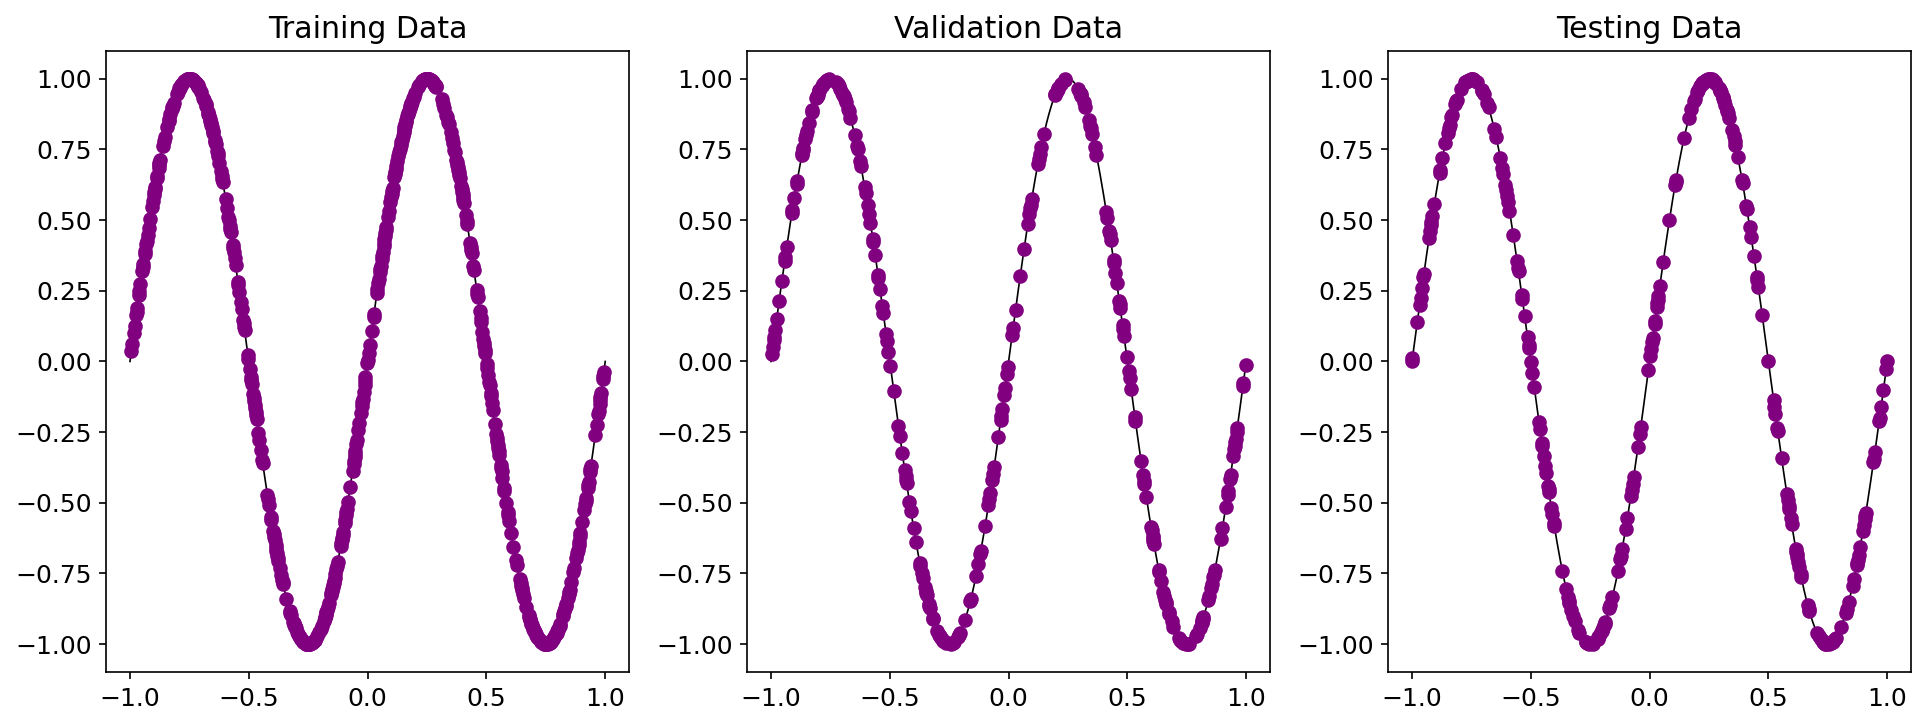

In [5]:
xtrain = xdata[trainind]
ytrain = ydata[trainind]
xval = xdata[valind]
yval = ydata[valind]
xtest = xdata[testind]
ytest = ydata[testind]

plt.figure(figsize=(13,5))
plt.subplot(1,3,1)
plt.plot(xdata,ydata,color='black',linewidth=0.8)
plt.plot(xtrain,ytrain,color='purple',marker='o',linestyle='None')
#plt.text(-0.6,0.8,'Training Data',fontsize=14)
plt.title('Training Data')

plt.subplot(1,3,2)
plt.plot(xdata,ydata,color='black',linewidth=0.8)
plt.plot(xval,yval,color='purple',marker='o',linestyle='None')
#plt.text(-0.6,0.8,'Validation Data',fontsize=14)
plt.title('Validation Data')

plt.subplot(1,3,3)
plt.plot(xdata,ydata,color='black',linewidth=0.8)
plt.plot(xtest,ytest,color='purple',marker='o',linestyle='None')
#plt.text(-0.6,0.8,'Testing Data',fontsize=14)
plt.title('Testing Data')

plt.tight_layout()
plt.show()

## Set some neural network parameters
Here we define parts of the neural network architecture and hyper-parameters. The starting values are arbitrary. **Play around with these to try to get the best fit! You can do this methodically and keep track of what changes you make, or just mess around with them informally.**

Default values:
* `learning_rate = 0.1`
* `batch_size = 3`
* `n_epochs = 10`
* `activation = 'tanh'`
* `hiddens = [5, 8]`
* `loss = 'mse'`

In [57]:
learning_rate = 0.1  # learning rate: suggest varying in powers of 10
batch_size = 3 # batch size: can be between 0 and the size of the dataset
n_epochs = 10 # number of epochs
activation = 'tanh' # activation function on hidden layers: valid options include 'sigmoid', 'relu', 'tanh', 'linear'
hiddens = [5, 8] # hidden layers: input as array, e.g., [5, 8] is two hidden layers that have 5 nodes and 8 nodes, respectively
loss = 'mse' # loss function: valid options include 'mse', 'mae'

* Full list of activation functions: [link to documentation](https://www.tensorflow.org/api_docs/python/tf/keras/activations)
* Full list of loss functions: [link to documentation](https://www.tensorflow.org/api_docs/python/tf/keras/losses)

## Make and train the model

In [58]:
nhiddens = len(hiddens)

model = tf.keras.models.Sequential()

# First hidden layer
model.add(tf.keras.layers.Dense(hiddens[0], activation=activation, input_shape=(1,),
                bias_initializer=tf.keras.initializers.RandomNormal(seed=random_seed),
                kernel_initializer=tf.keras.initializers.RandomNormal(seed=random_seed),
                ))

# and the rest of the layers
for ilayer in range(1,nhiddens):
    model.add(tf.keras.layers.Dense(hiddens[ilayer], activation=activation,
                    bias_initializer=tf.keras.initializers.RandomNormal(seed=random_seed),
                    kernel_initializer=tf.keras.initializers.RandomNormal(seed=random_seed),
                    )) 

# final layer
model.add(tf.keras.layers.Dense(1,activation='linear',
                bias_initializer=tf.keras.initializers.RandomNormal(seed=random_seed),
                kernel_initializer=tf.keras.initializers.RandomNormal(seed=random_seed),))


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate),
            loss=loss,   # loss function   
            metrics=['mae','mse']) 

history = model.fit(xtrain, ytrain, epochs=n_epochs, batch_size=batch_size, validation_data=(xval, yval), 
                shuffle=True, verbose=0)

## How well did it do?
The cell below prints figures displaying the model progress and prediction.  

The left figure shows the *training dynamics*: it reports how the loss function varies with time on both the training and evaluation/validation datasets. In general, we want the loss to decrease with time until it asymptotically approaches a small number, with similar performance on both the training and evaluation/validation datasets.  

The middle figure shows the true dataset and the prediction of the model on the training data. This reflects the model's performance on the data it has explicitly optimized for during the training process.

The right figure shows the true dataset and the prediction of the model on the validation/evaluation data. This reflects the model's performance on data that it has not seen during training, but we are reviewing to mamually update the hyperparameters.

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step


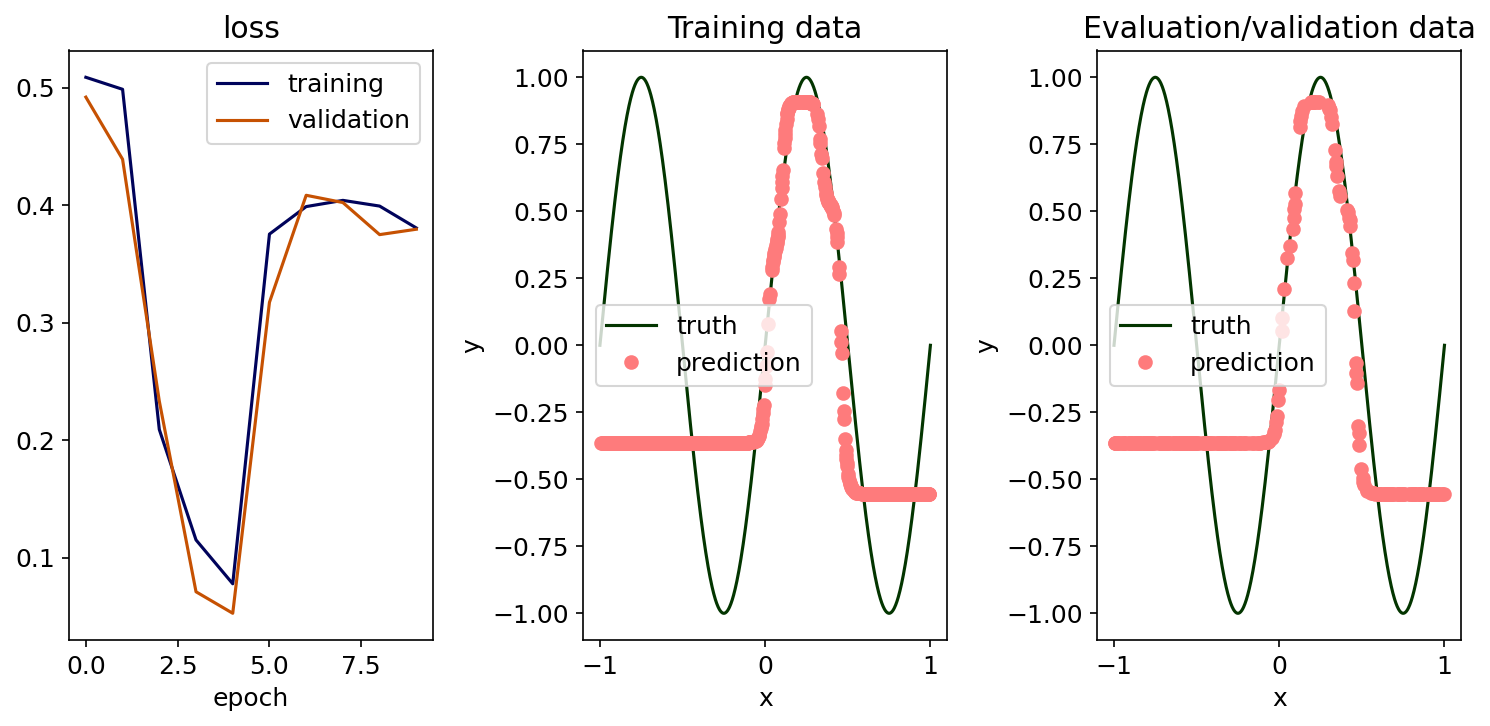

In [59]:
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.title('loss')
plt.plot(history.history['loss'], label='training', color='xkcd:dark blue')
plt.plot(history.history['val_loss'], label='validation', color='xkcd:dark orange')
plt.xlabel('epoch')
plt.legend()

ypred_train = model.predict(xtrain)
plt.subplot(1,3,2)
plt.plot(xdata, ydata, label='truth', color='xkcd:dark green')
plt.plot(xtrain, ypred_train, marker='o', linestyle='none', label='prediction', color='xkcd:salmon pink')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training data')
plt.legend()

ypred = model.predict(xval)

plt.subplot(1,3,3)
plt.plot(xdata, ydata, label='truth', color='xkcd:dark green')
plt.plot(xval, ypred, marker='o', linestyle='none', label='prediction', color='xkcd:salmon pink')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Evaluation/validation data')
plt.legend()

plt.tight_layout()
plt.show()

## Check on the testing data

Once you have a model that you're happy with based on your training and evaluation/validation data, you can run it on the testing data to see whether the performance generalized successfully to totally unseen data!

In [60]:
raise SystemError('Stopped before testing data; do not run until ready.') # Comment out this line to proceed once you are ready to run on the testing data

ypred = model.predict(xtest)

plt.subplot(1,2,2)
plt.plot(xdata, ydata, label='truth', color='xkcd:dark green')
plt.plot(xtest, ypred, marker='o', linestyle='none', label='prediction', color='xkcd:salmon pink')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicting the testing data')
plt.legend()

plt.tight_layout()
plt.show()

SystemError: Stopped before testing data; do not run until ready.